# 🛣️ Barbados Traffic Congestion Challenge - Advanced Features Model

This notebook provides an enhanced approach for the **Barbados Traffic Analysis Challenge** using advanced object tracking and motion features.

#### 🎯 **Objective**
Predict **traffic congestion** at a major Barbadian roundabout — *five minutes into the future* — using:
- Raw video feeds from **four synchronized cameras**
- **Advanced object detection and tracking** (YOLO + ByteTrack)
- **Multi-camera feature fusion**
- **Speed and flow analysis**

### 🔍 **Critical Requirement: Identify Driving Factors of Congestion**
Beyond high F1/Accuracy, top teams must deliver **insight**, not just predictions.

# Libraries

In [75]:
import os
import warnings
import subprocess
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Sklearn imports
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, balanced_accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# Install imbalanced-learn if not available
try:
    from imblearn.ensemble import BalancedRandomForestClassifier, BalancedBaggingClassifier, EasyEnsembleClassifier, RUSBoostClassifier
except ImportError:
    print("Installing imbalanced-learn...")
    subprocess.check_call(['pip', 'install', 'imbalanced-learn'])
    from imblearn.ensemble import BalancedRandomForestClassifier, BalancedBaggingClassifier, EasyEnsembleClassifier, RUSBoostClassifier

# Install XGBoost if not available
try:
    from xgboost import XGBClassifier
except ImportError:
    print("Installing xgboost...")
    subprocess.check_call(['pip', 'install', 'xgboost'])
    from xgboost import XGBClassifier

# Install LightGBM if not available
try:
    from lightgbm import LGBMClassifier
except ImportError:
    print("Installing lightgbm...")
    subprocess.check_call(['pip', 'install', 'lightgbm'])
    from lightgbm import LGBMClassifier

# Install CatBoost if not available
try:
    from catboost import CatBoostClassifier
except ImportError:
    print("Installing catboost...")
    subprocess.check_call(['pip', 'install', 'catboost'])
    from catboost import CatBoostClassifier

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


# Setup Environment

In [76]:
pd.set_option("display.max_rows", 70)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Configuration

Set the paths to your data files and features directory.

In [77]:
# Paths configuration
TRAIN_CSV = "Train.csv"
TEST_CSV = "TestInputSegments.csv"
SAMPLE_SUBMISSION_CSV = "SampleSubmission.csv"

# Path to the merged features directories from parallel processing
# TRAIN features: merged_features_2025-10-20-06-00-45.csv
TRAIN_FEATURES_DIR = "features_output"
# TEST features: test_features_2025-10-20-06-00-45.csv
TEST_FEATURES_DIR = "test_features_output"

# Check if features directories exist
if not os.path.exists(TRAIN_FEATURES_DIR):
    print(f"⚠️  Warning: Train features directory not found: {TRAIN_FEATURES_DIR}")
    print("Please run the feature extraction pipeline first:")
    print("  python parallel_process_dataset.py --workers 4")
else:
    print(f"✓ Train features directory found: {TRAIN_FEATURES_DIR}")

if not os.path.exists(TEST_FEATURES_DIR):
    print(f"⚠️  Warning: Test features directory not found: {TEST_FEATURES_DIR}")
    print("Please run the test feature extraction pipeline:")
    print("  python parallel_process_test_dataset.py --workers 4")
else:
    print(f"✓ Test features directory found: {TEST_FEATURES_DIR}")

✓ Train features directory found: features_output
✓ Test features directory found: test_features_output


# Import Preprocessing Module

Import the preprocessing module that contains all data loading and transformation logic.


In [ ]:
# Import the preprocessing module
from preprocessing import preprocess_data

print("✓ Preprocessing module imported successfully")


# Run Complete Preprocessing Pipeline

Run the complete preprocessing pipeline using the preprocessing module. This will:
1. Load CSV files (train, test, submission)
2. Extract timestamps from video filenames
3. Load advanced features from feature directories
4. Merge features with labels
5. Add temporal features (hour, day_week, is_weekend, etc.)
6. Encode categorical features (signaling)
7. Create long format dataset (melt ID_enter/ID_exit)
8. Add submission template rows
9. Select features for modeling
10. Shift features by 7 periods (for 5-min forecast)
11. Split into train/validation/test sets
12. Fill NaN values in test set with training medians


In [ ]:
# Run the complete preprocessing pipeline
result = preprocess_data(
    train_csv=TRAIN_CSV,
    test_csv=TEST_CSV,
    sample_submission_csv=SAMPLE_SUBMISSION_CSV,
    train_features_dir=TRAIN_FEATURES_DIR,
    test_features_dir=TEST_FEATURES_DIR,
    shift_periods=7,
    verbose=True
)

# Extract the results
training_df = result['training_df']
validation_df = result['validation_df']
testing_df = result['testing_df']
features_cols = result['features_cols']
sub = result['sub']

print(f"\n✓ Preprocessing complete!")
print(f"  Training samples: {len(training_df):,}")
print(f"  Validation samples: {len(validation_df):,}")
print(f"  Test samples: {len(testing_df):,}")
print(f"  Features: {len(features_cols)}")

# Show sample of training data
display(training_df[['view_label', 'time_segment_id', 'ID', 'congestion_rating'] + features_cols[:5]].head())


# Alternative: Step-by-step Preprocessing (Optional)

The cells below show the original step-by-step preprocessing approach.
You can skip these cells if you used the preprocessing pipeline above.

**Note:** The following cells from "Load Data" through "Split into Train/Validation/Test" are now replaced by the single preprocessing pipeline above.


# Load Data

Load the training labels, test segments, and sample submission.

In [78]:
# Load CSV files
train = pd.read_csv(TRAIN_CSV)
test = pd.read_csv(TEST_CSV)
sub = pd.read_csv(SAMPLE_SUBMISSION_CSV)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Submission shape: {sub.shape}")

display(train.head(2))
display(test.head(2))
display(sub.head(2))

Train shape: (16076, 14)
Test shape: (2640, 14)
Submission shape: (880, 3)


,responseId,view_label,ID_enter,ID_exit,videos,video_time,datetimestamp_start,datetimestamp_end,date,signaling,congestion_enter_rating,congestion_exit_rating,time_segment_id,cycle_phase
0,zYkHaeOdB7XOnvgP3YW5kQs,Norman Niles #1,time_segment_0_Norman Niles #1_congestion_ente...,time_segment_0_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-00-45.mp4,2025-10-20 06:00:45,2025-10-20 06:00:45,2025-10-20 06:01:44,2025-10-20,none,free flowing,free flowing,0,train
1,NYsHaeCRLq-vnvgPjoXZqA0,Norman Niles #1,time_segment_1_Norman Niles #1_congestion_ente...,time_segment_1_Norman Niles #1_congestion_exit...,normanniles1/normanniles1_2025-10-20-06-01-45.mp4,2025-10-20 06:01:45,2025-10-20 06:01:45,2025-10-20 06:02:44,2025-10-20,none,free flowing,free flowing,1,train


,responseId,view_label,ID_enter,ID_exit,videos,video_time,datetimestamp_start,datetimestamp_end,date,signaling,congestion_enter_rating,congestion_exit_rating,time_segment_id,cycle_phase
0,7IkHaYxe2IPY-A_IpprJDA,Norman Niles #1,time_segment_112_Norman Niles #1_congestion_en...,time_segment_112_Norman Niles #1_congestion_ex...,normanniles1/normanniles1_2025-10-20-07-52-45.mp4,2025-10-20 07:52:45,2025-10-20 07:52:45,2025-10-20 07:53:44,2025-10-20,none,free flowing,free flowing,112,test_input_15
1,zIkHaZe0Fr-envgP6uGTmAE,Norman Niles #1,time_segment_113_Norman Niles #1_congestion_en...,time_segment_113_Norman Niles #1_congestion_ex...,normanniles1/normanniles1_2025-10-20-07-53-45.mp4,2025-10-20 07:53:45,2025-10-20 07:53:45,2025-10-20 07:54:44,2025-10-20,none,free flowing,free flowing,113,test_input_15


,ID,Target,Target_Accuracy
0,time_segment_129_Norman Niles #1_congestion_en...,free flowing,free flowing
1,time_segment_130_Norman Niles #1_congestion_en...,heavy delay,heavy delay


# Extract Video Timestamps

Extract timestamps from video filenames to match with features.

In [79]:
import re

def extract_timestamp(video_path):
    """Extract timestamp from video filename"""
    # Pattern: YYYY-MM-DD-HH-MM-SS
    match = re.search(r'(\d{4}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2})', video_path)
    if match:
        return match.group(1)
    return None

# Extract timestamps
train['video_timestamp'] = train['videos'].apply(extract_timestamp)
test['video_timestamp'] = test['videos'].apply(extract_timestamp)

# Parse video_time to datetime
train['video_time'] = pd.to_datetime(train['video_time'])
test['video_time'] = pd.to_datetime(test['video_time'])

print(f"Train timestamps: {train['video_timestamp'].nunique()} unique")
print(f"Test timestamps: {test['video_timestamp'].nunique()} unique")

display(train[['videos', 'video_timestamp', 'video_time']].head(3))

Train timestamps: 4019 unique
Test timestamps: 660 unique


,videos,video_timestamp,video_time
0,normanniles1/normanniles1_2025-10-20-06-00-45.mp4,2025-10-20-06-00-45,2025-10-20 06:00:45
1,normanniles1/normanniles1_2025-10-20-06-01-45.mp4,2025-10-20-06-01-45,2025-10-20 06:01:45
2,normanniles1/normanniles1_2025-10-20-06-02-45.mp4,2025-10-20-06-02-45,2025-10-20 06:02:45


# Load Advanced Features

Load the pre-computed features from the object tracking pipeline.

These features include:
- **Entry/Exit flow metrics**: Vehicle counts and flow rates
- **Circulating flow metrics**: Occupancy and circulation patterns
- **Speed metrics**: Average speeds, min/max speeds
- **Origin-Destination matrices**: Traffic flow patterns
- **Temporal features**: Hour, day of week, rush hour indicators
- **Derived features**: Entry/exit balance, density indicators
- **Multi-camera fusion**: Combined features from all 4 cameras

In [80]:
def load_all_features(train_features_dir, test_features_dir):
    """
    Load all feature CSVs from both train and test features directories
    
    Args:
        train_features_dir: Directory with merged_features_*.csv files
        test_features_dir: Directory with test_features_*.csv files
    
    Returns:
        Tuple of (train_features_df, test_features_df)
    """
    train_features = None
    test_features = None
    
    # Load TRAIN features
    train_path = Path(train_features_dir)
    if train_path.exists():
        # Find all merged feature files
        feature_files = list(train_path.glob("merged_features_*.csv"))
        
        if feature_files:
            print(f"Found {len(feature_files)} train feature files")
            
            # Load all features
            dfs = []
            for file in tqdm(feature_files, desc="Loading train features"):
                try:
                    df = pd.read_csv(file)
                    # Extract timestamp from filename: merged_features_2025-10-20-06-00-45.csv
                    timestamp = file.stem.replace('merged_features_', '')
                    df['video_timestamp'] = timestamp
                    dfs.append(df)
                except Exception as e:
                    print(f"Error loading {file}: {e}")
            
            if dfs:
                train_features = pd.concat(dfs, ignore_index=True)
                print(f"✓ Loaded train features: {train_features.shape}")
        else:
            print(f"❌ No train feature files found in {train_features_dir}")
            print("Expected files like: merged_features_2025-10-20-06-00-45.csv")
    else:
        print(f"❌ Train features directory not found: {train_features_dir}")
    
    # Load TEST features
    test_path = Path(test_features_dir)
    if test_path.exists():
        # Find all test feature files
        feature_files = list(test_path.glob("test_features_*.csv"))
        
        if feature_files:
            print(f"Found {len(feature_files)} test feature files")
            
            # Load all features
            dfs = []
            for file in tqdm(feature_files, desc="Loading test features"):
                try:
                    df = pd.read_csv(file)
                    # Extract timestamp from filename: test_features_2025-10-20-06-00-45.csv
                    timestamp = file.stem.replace('test_features_', '')
                    df['video_timestamp'] = timestamp
                    dfs.append(df)
                except Exception as e:
                    print(f"Error loading {file}: {e}")
            
            if dfs:
                test_features = pd.concat(dfs, ignore_index=True)
                print(f"✓ Loaded test features: {test_features.shape}")
        else:
            print(f"❌ No test feature files found in {test_features_dir}")
            print("Expected files like: test_features_2025-10-20-06-00-45.csv")
    else:
        print(f"❌ Test features directory not found: {test_features_dir}")
    
    return train_features, test_features

# Load features from both directories
train_features, test_features = load_all_features(TRAIN_FEATURES_DIR, TEST_FEATURES_DIR)

if train_features is not None:
    print(f"\nTrain feature columns ({len(train_features.columns)}):")
    print(train_features.columns.tolist()[:20], "...")
    display(train_features.head())
    
if test_features is not None:
    print(f"\nTest feature columns ({len(test_features.columns)}):")
    print(test_features.columns.tolist()[:20], "...")
    display(test_features.head())

if train_features is None and test_features is None:
    print("\n⚠️  No features loaded. Using fallback to simple features only.")

Found 4009 train feature files


Loading train features: 100%|██████████| 4009/4009 [00:26<00:00, 153.89it/s]



✓ Loaded train features: (4009, 350)
Found 656 test feature files


Loading test features: 100%|██████████| 656/656 [00:04<00:00, 152.12it/s]



✓ Loaded test features: (656, 350)

Train feature columns (350):
['window_idx', 'start_time', 'end_time', 'window_duration', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_rush_hour', 'time_since_midnight', 'north_entry_count', 'north_exit_count', 'north_entry_flow_rate', 'north_exit_flow_rate', 'north_entry_count_car', 'north_entry_count_truck', 'north_entry_count_bus', 'north_exit_count_car', 'north_exit_count_truck', 'north_exit_count_bus', 'north_circulating_occupancy_avg'] ...


,window_idx,start_time,end_time,window_duration,hour_of_day,day_of_week,is_weekend,is_rush_hour,time_since_midnight,north_entry_count,north_exit_count,north_entry_flow_rate,north_exit_flow_rate,north_entry_count_car,north_entry_count_truck,north_entry_count_bus,north_exit_count_car,north_exit_count_truck,north_exit_count_bus,north_circulating_occupancy_avg,north_circulating_occupancy_max,north_circulating_flow_rate,north_speed_avg_km_h,north_speed_std_km_h,north_entry_speed_avg_km_h,north_circulating_speed_avg_km_h,north_entry_exit_balance,north_entry_circulating_ratio,north_circulating_density,north_entry_count_lag_1,north_entry_count_lag_2,north_entry_count_lag_3,north_entry_flow_rate_lag_1,north_entry_flow_rate_lag_2,north_entry_flow_rate_lag_3,north_exit_count_lag_1,north_exit_count_lag_2,north_exit_count_lag_3,north_exit_flow_rate_lag_1,north_exit_flow_rate_lag_2,north_exit_flow_rate_lag_3,north_circulating_occupancy_avg_lag_1,north_circulating_occupancy_avg_lag_2,north_circulating_occupancy_avg_lag_3,north_circulating_flow_rate_lag_1,north_circulating_flow_rate_lag_2,north_circulating_flow_rate_lag_3,north_speed_avg_km_h_lag_1,north_speed_avg_km_h_lag_2,north_speed_avg_km_h_lag_3,north_entry_count_rolling_mean_3,north_entry_count_rolling_std_3,north_entry_count_rolling_mean_6,north_entry_count_rolling_std_6,north_entry_count_rolling_mean_12,north_entry_count_rolling_std_12,north_entry_flow_rate_rolling_mean_3,north_entry_flow_rate_rolling_std_3,north_entry_flow_rate_rolling_mean_6,north_entry_flow_rate_rolling_std_6,north_entry_flow_rate_rolling_mean_12,north_entry_flow_rate_rolling_std_12,north_exit_count_rolling_mean_3,north_exit_count_rolling_std_3,north_exit_count_rolling_mean_6,north_exit_count_rolling_std_6,north_exit_count_rolling_mean_12,north_exit_count_rolling_std_12,north_exit_flow_rate_rolling_mean_3,north_exit_flow_rate_rolling_std_3,north_exit_flow_rate_rolling_mean_6,north_exit_flow_rate_rolling_std_6,north_exit_flow_rate_rolling_mean_12,north_exit_flow_rate_rolling_std_12,north_circulating_occupancy_avg_rolling_mean_3,north_circulating_occupancy_avg_rolling_std_3,north_circulating_occupancy_avg_rolling_mean_6,north_circulating_occupancy_avg_rolling_std_6,north_circulating_occupancy_avg_rolling_mean_12,north_circulating_occupancy_avg_rolling_std_12,north_speed_avg_km_h_rolling_mean_3,north_speed_avg_km_h_rolling_std_3,north_speed_avg_km_h_rolling_mean_6,north_speed_avg_km_h_rolling_std_6,north_speed_avg_km_h_rolling_mean_12,north_speed_avg_km_h_rolling_std_12,east_entry_count,east_exit_count,east_entry_flow_rate,east_exit_flow_rate,east_entry_count_car,east_entry_count_truck,east_entry_count_bus,east_exit_count_car,east_exit_count_truck,east_exit_count_bus,east_circulating_occupancy_avg,east_circulating_occupancy_max,east_circulating_flow_rate,east_speed_avg_km_h,east_speed_std_km_h,east_entry_speed_avg_km_h,east_circulating_speed_avg_km_h,east_entry_exit_balance,east_entry_circulating_ratio,east_circulating_density,east_entry_count_lag_1,east_entry_count_lag_2,east_entry_count_lag_3,east_entry_flow_rate_lag_1,east_entry_flow_rate_lag_2,east_entry_flow_rate_lag_3,east_exit_count_lag_1,east_exit_count_lag_2,east_exit_count_lag_3,east_exit_flow_rate_lag_1,east_exit_flow_rate_lag_2,east_exit_flow_rate_lag_3,east_circulating_occupancy_avg_lag_1,east_circulating_occupancy_avg_lag_2,east_circulating_occupancy_avg_lag_3,east_circulating_flow_rate_lag_1,east_circulating_flow_rate_lag_2,east_circulating_flow_rate_lag_3,east_speed_avg_km_h_lag_1,east_speed_avg_km_h_lag_2,east_speed_avg_km_h_lag_3,east_entry_count_rolling_mean_3,east_entry_count_rolling_std_3,east_entry_count_rolling_mean_6,east_entry_count_rolling_std_6,east_entry_count_rolling_mean_12,east_entry_count_rolling_std_12,east_entry_flow_rate_rolling_mean_3,east_entry_flow_rate_rolling_std_3,east_entry_flow_rate_rolling_mean_6,east_entry_flow_rate_rolling_std_6,east_entry_flow_rate_rolling_mean_12,east_entry_flow_rate_rolling_std_12,east_exit_count_rolli


Test feature columns (350):
['window_idx', 'start_time', 'end_time', 'window_duration', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_rush_hour', 'time_since_midnight', 'north_entry_count', 'north_exit_count', 'north_entry_flow_rate', 'north_exit_flow_rate', 'north_entry_count_car', 'north_entry_count_truck', 'north_entry_count_bus', 'north_exit_count_car', 'north_exit_count_truck', 'north_exit_count_bus', 'north_circulating_occupancy_avg'] ...


,window_idx,start_time,end_time,window_duration,hour_of_day,day_of_week,is_weekend,is_rush_hour,time_since_midnight,north_entry_count,north_exit_count,north_entry_flow_rate,north_exit_flow_rate,north_entry_count_car,north_entry_count_truck,north_entry_count_bus,north_exit_count_car,north_exit_count_truck,north_exit_count_bus,north_circulating_occupancy_avg,north_circulating_occupancy_max,north_circulating_flow_rate,north_speed_avg_km_h,north_speed_std_km_h,north_entry_speed_avg_km_h,north_circulating_speed_avg_km_h,north_entry_exit_balance,north_entry_circulating_ratio,north_circulating_density,north_entry_count_lag_1,north_entry_count_lag_2,north_entry_count_lag_3,north_entry_flow_rate_lag_1,north_entry_flow_rate_lag_2,north_entry_flow_rate_lag_3,north_exit_count_lag_1,north_exit_count_lag_2,north_exit_count_lag_3,north_exit_flow_rate_lag_1,north_exit_flow_rate_lag_2,north_exit_flow_rate_lag_3,north_circulating_occupancy_avg_lag_1,north_circulating_occupancy_avg_lag_2,north_circulating_occupancy_avg_lag_3,north_circulating_flow_rate_lag_1,north_circulating_flow_rate_lag_2,north_circulating_flow_rate_lag_3,north_speed_avg_km_h_lag_1,north_speed_avg_km_h_lag_2,north_speed_avg_km_h_lag_3,north_entry_count_rolling_mean_3,north_entry_count_rolling_std_3,north_entry_count_rolling_mean_6,north_entry_count_rolling_std_6,north_entry_count_rolling_mean_12,north_entry_count_rolling_std_12,north_entry_flow_rate_rolling_mean_3,north_entry_flow_rate_rolling_std_3,north_entry_flow_rate_rolling_mean_6,north_entry_flow_rate_rolling_std_6,north_entry_flow_rate_rolling_mean_12,north_entry_flow_rate_rolling_std_12,north_exit_count_rolling_mean_3,north_exit_count_rolling_std_3,north_exit_count_rolling_mean_6,north_exit_count_rolling_std_6,north_exit_count_rolling_mean_12,north_exit_count_rolling_std_12,north_exit_flow_rate_rolling_mean_3,north_exit_flow_rate_rolling_std_3,north_exit_flow_rate_rolling_mean_6,north_exit_flow_rate_rolling_std_6,north_exit_flow_rate_rolling_mean_12,north_exit_flow_rate_rolling_std_12,north_circulating_occupancy_avg_rolling_mean_3,north_circulating_occupancy_avg_rolling_std_3,north_circulating_occupancy_avg_rolling_mean_6,north_circulating_occupancy_avg_rolling_std_6,north_circulating_occupancy_avg_rolling_mean_12,north_circulating_occupancy_avg_rolling_std_12,north_speed_avg_km_h_rolling_mean_3,north_speed_avg_km_h_rolling_std_3,north_speed_avg_km_h_rolling_mean_6,north_speed_avg_km_h_rolling_std_6,north_speed_avg_km_h_rolling_mean_12,north_speed_avg_km_h_rolling_std_12,east_entry_count,east_exit_count,east_entry_flow_rate,east_exit_flow_rate,east_entry_count_car,east_entry_count_truck,east_entry_count_bus,east_exit_count_car,east_exit_count_truck,east_exit_count_bus,east_circulating_occupancy_avg,east_circulating_occupancy_max,east_circulating_flow_rate,east_speed_avg_km_h,east_speed_std_km_h,east_entry_speed_avg_km_h,east_circulating_speed_avg_km_h,east_entry_exit_balance,east_entry_circulating_ratio,east_circulating_density,east_entry_count_lag_1,east_entry_count_lag_2,east_entry_count_lag_3,east_entry_flow_rate_lag_1,east_entry_flow_rate_lag_2,east_entry_flow_rate_lag_3,east_exit_count_lag_1,east_exit_count_lag_2,east_exit_count_lag_3,east_exit_flow_rate_lag_1,east_exit_flow_rate_lag_2,east_exit_flow_rate_lag_3,east_circulating_occupancy_avg_lag_1,east_circulating_occupancy_avg_lag_2,east_circulating_occupancy_avg_lag_3,east_circulating_flow_rate_lag_1,east_circulating_flow_rate_lag_2,east_circulating_flow_rate_lag_3,east_speed_avg_km_h_lag_1,east_speed_avg_km_h_lag_2,east_speed_avg_km_h_lag_3,east_entry_count_rolling_mean_3,east_entry_count_rolling_std_3,east_entry_count_rolling_mean_6,east_entry_count_rolling_std_6,east_entry_count_rolling_mean_12,east_entry_count_rolling_std_12,east_entry_flow_rate_rolling_mean_3,east_entry_flow_rate_rolling_std_3,east_entry_flow_rate_rolling_mean_6,east_entry_flow_rate_rolling_std_6,east_entry_flow_rate_rolling_mean_12,east_entry_flow_rate_rolling_std_12,east_exit_count_rolli

# Merge Features with Labels

Merge the advanced features with training labels and test data.

In [84]:
# Merge train data with train features
if train_features is not None:
    train_df = train.merge(
        train_features,
        on='video_timestamp',
        how='left'
    )
    print(f"Train with features: {train_df.shape}")
    
    # Check merge quality
    missing_features_train = train_df[train_features.columns[0]].isnull().sum()
    print(f"  Train: {missing_features_train}/{len(train_df)} missing features ({100*missing_features_train/len(train_df):.1f}%)")
else:
    print("Using original train data without advanced features")
    train_df = train.copy()

# Merge test data with test features
if test_features is not None:
    test_df = test.merge(
        test_features,
        on='video_timestamp',
        how='left'
    )
    print(f"Test with features: {test_df.shape}")
    
    # Check merge quality
    missing_features_test = test_df[test_features.columns[0]].isnull().sum()
    print(f"  Test: {missing_features_test}/{len(test_df)} missing features ({100*missing_features_test/len(test_df):.1f}%)")
else:
    print("Using original test data without advanced features")
    test_df = test.copy()

print(f"\nMerge Summary:")
print(f"  Train dataset: {train_df.shape}")
print(f"  Test dataset: {test_df.shape}")

display(train_df.head(2))
display(test_df.head(2))

Train with features: (16076, 364)
  Train: 40/16076 missing features (0.2%)
Test with features: (2640, 364)
  Test: 16/2640 missing features (0.6%)

Merge Summary:
  Train dataset: (16076, 364)
  Test dataset: (2640, 364)


,responseId,view_label,ID_enter,ID_exit,videos,video_time,datetimestamp_start,datetimestamp_end,date,signaling,congestion_enter_rating,congestion_exit_rating,time_segment_id,cycle_phase,video_timestamp,window_idx,start_time,end_time,window_duration,hour_of_day,day_of_week,is_weekend,is_rush_hour,time_since_midnight,north_entry_count,north_exit_count,north_entry_flow_rate,north_exit_flow_rate,north_entry_count_car,north_entry_count_truck,north_entry_count_bus,north_exit_count_car,north_exit_count_truck,north_exit_count_bus,north_circulating_occupancy_avg,north_circulating_occupancy_max,north_circulating_flow_rate,north_speed_avg_km_h,north_speed_std_km_h,north_entry_speed_avg_km_h,north_circulating_speed_avg_km_h,north_entry_exit_balance,north_entry_circulating_ratio,north_circulating_density,north_entry_count_lag_1,north_entry_count_lag_2,north_entry_count_lag_3,north_entry_flow_rate_lag_1,north_entry_flow_rate_lag_2,north_entry_flow_rate_lag_3,north_exit_count_lag_1,north_exit_count_lag_2,north_exit_count_lag_3,north_exit_flow_rate_lag_1,north_exit_flow_rate_lag_2,north_exit_flow_rate_lag_3,north_circulating_occupancy_avg_lag_1,north_circulating_occupancy_avg_lag_2,north_circulating_occupancy_avg_lag_3,north_circulating_flow_rate_lag_1,north_circulating_flow_rate_lag_2,north_circulating_flow_rate_lag_3,north_speed_avg_km_h_lag_1,north_speed_avg_km_h_lag_2,north_speed_avg_km_h_lag_3,north_entry_count_rolling_mean_3,north_entry_count_rolling_std_3,north_entry_count_rolling_mean_6,north_entry_count_rolling_std_6,north_entry_count_rolling_mean_12,north_entry_count_rolling_std_12,north_entry_flow_rate_rolling_mean_3,north_entry_flow_rate_rolling_std_3,north_entry_flow_rate_rolling_mean_6,north_entry_flow_rate_rolling_std_6,north_entry_flow_rate_rolling_mean_12,north_entry_flow_rate_rolling_std_12,north_exit_count_rolling_mean_3,north_exit_count_rolling_std_3,north_exit_count_rolling_mean_6,north_exit_count_rolling_std_6,north_exit_count_rolling_mean_12,north_exit_count_rolling_std_12,north_exit_flow_rate_rolling_mean_3,north_exit_flow_rate_rolling_std_3,north_exit_flow_rate_rolling_mean_6,north_exit_flow_rate_rolling_std_6,north_exit_flow_rate_rolling_mean_12,north_exit_flow_rate_rolling_std_12,north_circulating_occupancy_avg_rolling_mean_3,north_circulating_occupancy_avg_rolling_std_3,north_circulating_occupancy_avg_rolling_mean_6,north_circulating_occupancy_avg_rolling_std_6,north_circulating_occupancy_avg_rolling_mean_12,north_circulating_occupancy_avg_rolling_std_12,north_speed_avg_km_h_rolling_mean_3,north_speed_avg_km_h_rolling_std_3,north_speed_avg_km_h_rolling_mean_6,north_speed_avg_km_h_rolling_std_6,north_speed_avg_km_h_rolling_mean_12,north_speed_avg_km_h_rolling_std_12,east_entry_count,east_exit_count,east_entry_flow_rate,east_exit_flow_rate,east_entry_count_car,east_entry_count_truck,east_entry_count_bus,east_exit_count_car,east_exit_count_truck,east_exit_count_bus,east_circulating_occupancy_avg,east_circulating_occupancy_max,east_circulating_flow_rate,east_speed_avg_km_h,east_speed_std_km_h,east_entry_speed_avg_km_h,east_circulating_speed_avg_km_h,east_entry_exit_balance,east_entry_circulating_ratio,east_circulating_density,east_entry_count_lag_1,east_entry_count_lag_2,east_entry_count_lag_3,east_entry_flow_rate_lag_1,east_entry_flow_rate_lag_2,east_entry_flow_rate_lag_3,east_exit_count_lag_1,east_exit_count_lag_2,east_exit_count_lag_3,east_exit_flow_rate_lag_1,east_exit_flow_rate_lag_2,east_exit_flow_rate_lag_3,east_circulating_occupancy_avg_lag_1,east_circulating_occupancy_avg_lag_2,east_circulating_occupancy_avg_lag_3,east_circulating_flow_rate_lag_1,east_circulating_flow_rate_lag_2,east_circulating_flow_rate_lag_3,east_speed_avg_km_h_lag_1,east_speed_avg_km_h_lag_2,east_speed_avg_km_h_lag_3,east_entry_count_rolling_mean_3,east_entry_count_rolling_std_3,east_entry_count_rolling_mean_6,east_entry_count_rolling_std_6,east_entry_count_rolling_mean_12,east_entry_count_rolling_std_12,east_entry_flow_rate_rolling_mean_3

,responseId,view_label,ID_enter,ID_exit,videos,video_time,datetimestamp_start,datetimestamp_end,date,signaling,congestion_enter_rating,congestion_exit_rating,time_segment_id,cycle_phase,video_timestamp,window_idx,start_time,end_time,window_duration,hour_of_day,day_of_week,is_weekend,is_rush_hour,time_since_midnight,north_entry_count,north_exit_count,north_entry_flow_rate,north_exit_flow_rate,north_entry_count_car,north_entry_count_truck,north_entry_count_bus,north_exit_count_car,north_exit_count_truck,north_exit_count_bus,north_circulating_occupancy_avg,north_circulating_occupancy_max,north_circulating_flow_rate,north_speed_avg_km_h,north_speed_std_km_h,north_entry_speed_avg_km_h,north_circulating_speed_avg_km_h,north_entry_exit_balance,north_entry_circulating_ratio,north_circulating_density,north_entry_count_lag_1,north_entry_count_lag_2,north_entry_count_lag_3,north_entry_flow_rate_lag_1,north_entry_flow_rate_lag_2,north_entry_flow_rate_lag_3,north_exit_count_lag_1,north_exit_count_lag_2,north_exit_count_lag_3,north_exit_flow_rate_lag_1,north_exit_flow_rate_lag_2,north_exit_flow_rate_lag_3,north_circulating_occupancy_avg_lag_1,north_circulating_occupancy_avg_lag_2,north_circulating_occupancy_avg_lag_3,north_circulating_flow_rate_lag_1,north_circulating_flow_rate_lag_2,north_circulating_flow_rate_lag_3,north_speed_avg_km_h_lag_1,north_speed_avg_km_h_lag_2,north_speed_avg_km_h_lag_3,north_entry_count_rolling_mean_3,north_entry_count_rolling_std_3,north_entry_count_rolling_mean_6,north_entry_count_rolling_std_6,north_entry_count_rolling_mean_12,north_entry_count_rolling_std_12,north_entry_flow_rate_rolling_mean_3,north_entry_flow_rate_rolling_std_3,north_entry_flow_rate_rolling_mean_6,north_entry_flow_rate_rolling_std_6,north_entry_flow_rate_rolling_mean_12,north_entry_flow_rate_rolling_std_12,north_exit_count_rolling_mean_3,north_exit_count_rolling_std_3,north_exit_count_rolling_mean_6,north_exit_count_rolling_std_6,north_exit_count_rolling_mean_12,north_exit_count_rolling_std_12,north_exit_flow_rate_rolling_mean_3,north_exit_flow_rate_rolling_std_3,north_exit_flow_rate_rolling_mean_6,north_exit_flow_rate_rolling_std_6,north_exit_flow_rate_rolling_mean_12,north_exit_flow_rate_rolling_std_12,north_circulating_occupancy_avg_rolling_mean_3,north_circulating_occupancy_avg_rolling_std_3,north_circulating_occupancy_avg_rolling_mean_6,north_circulating_occupancy_avg_rolling_std_6,north_circulating_occupancy_avg_rolling_mean_12,north_circulating_occupancy_avg_rolling_std_12,north_speed_avg_km_h_rolling_mean_3,north_speed_avg_km_h_rolling_std_3,north_speed_avg_km_h_rolling_mean_6,north_speed_avg_km_h_rolling_std_6,north_speed_avg_km_h_rolling_mean_12,north_speed_avg_km_h_rolling_std_12,east_entry_count,east_exit_count,east_entry_flow_rate,east_exit_flow_rate,east_entry_count_car,east_entry_count_truck,east_entry_count_bus,east_exit_count_car,east_exit_count_truck,east_exit_count_bus,east_circulating_occupancy_avg,east_circulating_occupancy_max,east_circulating_flow_rate,east_speed_avg_km_h,east_speed_std_km_h,east_entry_speed_avg_km_h,east_circulating_speed_avg_km_h,east_entry_exit_balance,east_entry_circulating_ratio,east_circulating_density,east_entry_count_lag_1,east_entry_count_lag_2,east_entry_count_lag_3,east_entry_flow_rate_lag_1,east_entry_flow_rate_lag_2,east_entry_flow_rate_lag_3,east_exit_count_lag_1,east_exit_count_lag_2,east_exit_count_lag_3,east_exit_flow_rate_lag_1,east_exit_flow_rate_lag_2,east_exit_flow_rate_lag_3,east_circulating_occupancy_avg_lag_1,east_circulating_occupancy_avg_lag_2,east_circulating_occupancy_avg_lag_3,east_circulating_flow_rate_lag_1,east_circulating_flow_rate_lag_2,east_circulating_flow_rate_lag_3,east_speed_avg_km_h_lag_1,east_speed_avg_km_h_lag_2,east_speed_avg_km_h_lag_3,east_entry_count_rolling_mean_3,east_entry_count_rolling_std_3,east_entry_count_rolling_mean_6,east_entry_count_rolling_std_6,east_entry_count_rolling_mean_12,east_entry_count_rolling_std_12,east_entry_flow_rate_rolling_mean_3

# Add Temporal Features

Extract time-based features from video timestamps.

In [85]:
def add_time_features(df, time_col="video_time"):
    """Add temporal features from datetime column"""
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df["day_week"] = df[time_col].dt.day_of_week   # 0=Mon, 6=Sun
    df["hour"] = df[time_col].dt.hour              # 0–23
    df["Date"] = df[time_col].dt.date
    df["minute"] = df[time_col].dt.minute
    df["is_weekend"] = (df["day_week"] >= 5).astype(int)
    df["is_rush_hour"] = df["hour"].apply(lambda x: 1 if x in [7, 8, 9, 16, 17, 18] else 0)
    return df

train_df = add_time_features(train_df)
test_df = add_time_features(test_df)

print("Added temporal features:")
print("  - day_week, hour, Date, minute")
print("  - is_weekend, is_rush_hour")
display(train_df[['video_time', 'day_week', 'hour', 'is_weekend', 'is_rush_hour']].head())

Added temporal features:
  - day_week, hour, Date, minute
  - is_weekend, is_rush_hour


,video_time,day_week,hour,is_weekend,is_rush_hour
0,2025-10-20 06:00:45,0,6,0,0
1,2025-10-20 06:01:45,0,6,0,0
2,2025-10-20 06:02:45,0,6,0,0
3,2025-10-20 06:03:45,0,6,0,0
4,2025-10-20 06:04:45,0,6,0,0


# Encode Categorical Features

In [86]:
# Encode signaling
categories = pd.concat([train_df['signaling'], test_df['signaling']]).unique()
train_df['signaling'] = pd.Categorical(train_df['signaling'], categories=categories).codes
test_df['signaling']  = pd.Categorical(test_df['signaling'], categories=categories).codes

print("Encoded signaling categories")
print(f"Train signaling distribution:\n{train_df['signaling'].value_counts()}")

Encoded signaling categories
Train signaling distribution:
signaling
0    8811
1    4074
2    2594
3     597
Name: count, dtype: int64


# Prepare Submission Format

Following the original notebook structure to ensure proper submission file preparation.

In [87]:
# Define column groups
id_cols = ['view_label', 'time_segment_id']
labels_cols = ['congestion_enter_rating', 'congestion_exit_rating']

# Combine train and test
final_df = pd.concat([train_df, test_df], ignore_index=True)

print(f"Combined dataset: {final_df.shape}")
display(final_df[['view_label', 'time_segment_id', 'cycle_phase'] + labels_cols].head())

Combined dataset: (18716, 368)


,view_label,time_segment_id,cycle_phase,congestion_enter_rating,congestion_exit_rating
0,Norman Niles #1,0,train,free flowing,free flowing
1,Norman Niles #1,1,train,free flowing,free flowing
2,Norman Niles #1,2,train,free flowing,free flowing
3,Norman Niles #1,3,train,free flowing,free flowing
4,Norman Niles #1,4,train,free flowing,free flowing


In [88]:
# Melt ID_enter and ID_exit into a single 'ID' column
long_df = final_df.melt(
    id_vars=[col for col in final_df.columns if col not in ['ID_enter', 'ID_exit']],
    value_vars=['ID_enter', 'ID_exit'],
    var_name='ID_type',
    value_name='ID'
)

# Create single congestion_rating column
long_df['congestion_rating'] = long_df.apply(
    lambda row: row['congestion_enter_rating'] 
                if row['ID_type'] == 'ID_enter' 
                else row['congestion_exit_rating'],
    axis=1
)
long_df = long_df.drop(columns=['congestion_enter_rating', 'congestion_exit_rating'])

print(f"Long format dataset: {long_df.shape}")
display(long_df[['view_label', 'time_segment_id', 'ID_type', 'ID', 'congestion_rating', 'cycle_phase']].head())

Long format dataset: (37432, 367)


,view_label,time_segment_id,ID_type,ID,congestion_rating,cycle_phase
0,Norman Niles #1,0,ID_enter,time_segment_0_Norman Niles #1_congestion_ente...,free flowing,train
1,Norman Niles #1,1,ID_enter,time_segment_1_Norman Niles #1_congestion_ente...,free flowing,train
2,Norman Niles #1,2,ID_enter,time_segment_2_Norman Niles #1_congestion_ente...,free flowing,train
3,Norman Niles #1,3,ID_enter,time_segment_3_Norman Niles #1_congestion_ente...,free flowing,train
4,Norman Niles #1,4,ID_enter,time_segment_4_Norman Niles #1_congestion_ente...,free flowing,train


In [89]:
# Parse submission file to add test_output_5 rows
ss = sub.copy()
ss['view_label'] = ss['ID'].apply(lambda x: x.split('_')[3])
ss['time_segment_id'] = ss['ID'].apply(lambda x: int(x.split('_')[2]))
ss['ID_type'] = ss['ID'].apply(lambda x: 'ID_' + x.split('#')[1].split('_')[2])
ss['cycle_phase'] = "test_output_5"
ss = ss.drop(columns=['Target', 'Target_Accuracy'])

print(f"Submission template: {ss.shape}")
display(ss.head())

Submission template: (880, 5)


,ID,view_label,time_segment_id,ID_type,cycle_phase
0,time_segment_129_Norman Niles #1_congestion_en...,Norman Niles #1,129,ID_enter,test_output_5
1,time_segment_130_Norman Niles #1_congestion_en...,Norman Niles #1,130,ID_enter,test_output_5
2,time_segment_131_Norman Niles #1_congestion_en...,Norman Niles #1,131,ID_enter,test_output_5
3,time_segment_132_Norman Niles #1_congestion_en...,Norman Niles #1,132,ID_enter,test_output_5
4,time_segment_133_Norman Niles #1_congestion_en...,Norman Niles #1,133,ID_enter,test_output_5


In [90]:
# Combine with submission template
merged_df = pd.concat([long_df, ss], ignore_index=True)
merged_df = merged_df.sort_values(by=['view_label', 'ID_type', 'time_segment_id'])
merged_df = merged_df.reset_index(drop=True)

print(f"Merged dataset with submission rows: {merged_df.shape}")
print(f"Cycle phases: {merged_df['cycle_phase'].unique()}")

# Show transition from test_input_15 to test_output_5
sample = merged_df[
    (merged_df['view_label'] == 'Norman Niles #1') & 
    (merged_df['ID_type'] == 'ID_enter') &
    (merged_df['time_segment_id'].between(193, 200))
][['view_label', 'time_segment_id', 'ID', 'cycle_phase', 'congestion_rating']]

display(sample)

Merged dataset with submission rows: (38312, 367)
Cycle phases: ['train' 'test_input_15' 'test_output_5']


,view_label,time_segment_id,ID,cycle_phase,congestion_rating
191,Norman Niles #1,193,time_segment_193_Norman Niles #1_congestion_en...,test_input_15,free flowing
192,Norman Niles #1,194,time_segment_194_Norman Niles #1_congestion_en...,test_input_15,free flowing
193,Norman Niles #1,195,time_segment_195_Norman Niles #1_congestion_en...,test_input_15,free flowing
194,Norman Niles #1,198,time_segment_198_Norman Niles #1_congestion_en...,test_output_5,NaN
195,Norman Niles #1,199,time_segment_199_Norman Niles #1_congestion_en...,test_output_5,NaN
196,Norman Niles #1,200,time_segment_200_Norman Niles #1_congestion_en...,test_output_5,NaN


# Select Features for Modeling

Identify which features to use for prediction.

In [91]:
# Base features (always available)
base_features = [
    'signaling', 'day_week', 'hour', 'minute',
    'is_weekend', 'is_rush_hour'
]

# Advanced features (if available from tracking pipeline)
advanced_features = []
if train_features is not None or test_features is not None:
    # Use whichever feature set is available to get column names
    feature_source = train_features if train_features is not None else test_features
    
    # Entry/Exit flow features
    flow_features = [
        col for col in merged_df.columns 
        if any(x in col for x in ['entry_count', 'exit_count', 'entry_flow', 'exit_flow'])
    ]
    
    # Circulating features
    circulating_features = [
        col for col in merged_df.columns
        if 'circulating' in col
    ]
    
    # Speed features
    speed_features = [
        col for col in merged_df.columns
        if 'speed' in col
    ]
    
    # OD features
    od_features = [
        col for col in merged_df.columns
        if 'od_' in col
    ]
    
    # Multi-camera features (with camera prefixes)
    camera_features = [
        col for col in merged_df.columns
        if any(cam in col for cam in ['cam1_', 'cam2_', 'cam3_', 'cam4_'])
    ]
    
    # Derived features
    derived_features = [
        col for col in merged_df.columns
        if any(x in col for x in ['balance', 'ratio', 'density', 'imbalance'])
    ]
    
    advanced_features = (
        flow_features + circulating_features + speed_features + 
        od_features + camera_features + derived_features
    )
    
    # Remove duplicates
    advanced_features = list(set(advanced_features))

# Combine all features
all_features = base_features + advanced_features

# Filter to only existing columns
features_cols = [col for col in all_features if col in merged_df.columns]

print(f"Selected {len(features_cols)} features:")
print(f"  - Base features: {len(base_features)}")
print(f"  - Advanced features: {len(advanced_features)}")

# Check feature completeness
print(f"\nFeature completeness check:")
complete_features = []
for col in features_cols:
    nan_count = merged_df[col].isna().sum()
    nan_pct = 100 * nan_count / len(merged_df)
    if nan_pct < 100:  # Feature has at least some values
        complete_features.append(col)
    if nan_pct > 50:  # Warn about high NaN percentage
        print(f"  ⚠️ {col}: {nan_pct:.1f}% NaN")

if len(complete_features) < len(features_cols):
    print(f"\n⚠️ {len(features_cols) - len(complete_features)} features are completely empty (100% NaN)")
    features_cols = complete_features  # Use only features with values
    print(f"Using {len(features_cols)} features with actual values")

print(f"\nFinal feature list ({len(features_cols)} features):")
for i, feat in enumerate(features_cols, 1):
    print(f"  {i}. {feat}")

Selected 333 features:
  - Base features: 6
  - Advanced features: 327

Feature completeness check:
  ⚠️ south_entry_flow_rate_rolling_std_12: 100.0% NaN
  ⚠️ east_exit_flow_rate_rolling_std_3: 100.0% NaN
  ⚠️ north_circulating_occupancy_avg_lag_3: 100.0% NaN
  ⚠️ north_circulating_flow_rate_lag_3: 100.0% NaN
  ⚠️ north_exit_count_lag_2: 100.0% NaN
  ⚠️ east_entry_count_rolling_std_12: 100.0% NaN
  ⚠️ south_circulating_flow_rate_lag_3: 100.0% NaN
  ⚠️ west_exit_count_rolling_std_12: 100.0% NaN
  ⚠️ west_circulating_occupancy_avg_lag_2: 100.0% NaN
  ⚠️ west_exit_count_rolling_std_6: 100.0% NaN
  ⚠️ east_speed_avg_km_h_rolling_std_12: 100.0% NaN
  ⚠️ north_exit_flow_rate_rolling_std_6: 100.0% NaN
  ⚠️ east_entry_count_lag_3: 100.0% NaN
  ⚠️ south_speed_avg_km_h_rolling_std_12: 100.0% NaN
  ⚠️ south_circulating_occupancy_avg_lag_3: 100.0% NaN
  ⚠️ east_circulating_occupancy_avg_rolling_std_3: 100.0% NaN
  ⚠️ north_speed_avg_km_h_lag_1: 100.0% NaN
  ⚠️ north_entry_flow_rate_lag_3: 100.0% N

# Prepare data with proper column selection
# Only shift the features that actually exist and have values
available_features = [col for col in features_cols if col in merged_df.columns and merged_df[col].notna().any()]

print(f"Available features for shifting: {len(available_features)}/{len(features_cols)}")
if len(available_features) < len(features_cols):
    missing = set(features_cols) - set(available_features)
    print(f"Features with all NaN values: {missing}")

# Apply shift only on available features
shifted_df = merged_df.groupby(['view_label', 'ID_type'], as_index=False)[available_features].shift(7)
shifted_df['ID'] = merged_df['ID'].values
shifted_df['cycle_phase'] = merged_df['cycle_phase'].values
shifted_df['congestion_rating'] = merged_df['congestion_rating'].values
shifted_df['view_label'] = merged_df['view_label'].values
shifted_df['ID_type'] = merged_df['ID_type'].values

# IMPORTANT: Only drop NaN for train and validation, NOT for test_output_5
# For test_output_5, we need to keep all rows (even with NaN) and fill them
initial_count = len(shifted_df)

# Split before dropping NaN
train_and_val_mask = shifted_df['cycle_phase'].isin(['train', 'test_input_15'])
test_mask = shifted_df['cycle_phase'] == 'test_output_5'

# Drop NaN only from train/validation
train_and_val_df = shifted_df[train_and_val_mask].dropna(subset=available_features)
test_df_shifted = shifted_df[test_mask].copy()  # Keep all test rows

print(f"\nAfter shifting:")
print(f"  Train+Validation (after dropna): {len(train_and_val_df)} rows")
print(f"  Test (kept all rows): {len(test_df_shifted)} rows")

# Combine back
shifted_df = pd.concat([train_and_val_df, test_df_shifted], ignore_index=True)

print(f"\nCombined shifted dataset: {shifted_df.shape}")
print(f"Dropped {initial_count - len(shifted_df)} rows from train/val (expected: ~7 per view/ID_type group)")
print(f"Remaining rows by cycle_phase:")
print(shifted_df['cycle_phase'].value_counts())

if len(shifted_df[shifted_df['cycle_phase'] == 'test_output_5']) != 880:
    print(f"\n⚠️ WARNING: Expected 880 test rows, got {len(shifted_df[shifted_df['cycle_phase'] == 'test_output_5'])}")

display(shifted_df.head())

In [92]:
# Prepare data with proper column selection
# Only shift the features that actually exist and have values
available_features = [col for col in features_cols if col in merged_df.columns and merged_df[col].notna().any()]

print(f"Available features for shifting: {len(available_features)}/{len(features_cols)}")
if len(available_features) < len(features_cols):
    missing = set(features_cols) - set(available_features)
    print(f"Features with all NaN values: {missing}")

# Apply shift only on available features
shifted_df = merged_df.groupby(['view_label', 'ID_type'], as_index=False)[available_features].shift(7)
shifted_df['ID'] = merged_df['ID'].values
shifted_df['cycle_phase'] = merged_df['cycle_phase'].values
shifted_df['congestion_rating'] = merged_df['congestion_rating'].values
shifted_df['view_label'] = merged_df['view_label'].values
shifted_df['ID_type'] = merged_df['ID_type'].values

# IMPORTANT: Only drop NaN for train and validation, NOT for test_output_5
# For test_output_5, we need to keep all rows (even with NaN) and fill them
initial_count = len(shifted_df)

# Split before dropping NaN
train_and_val_mask = shifted_df['cycle_phase'].isin(['train', 'test_input_15'])
test_mask = shifted_df['cycle_phase'] == 'test_output_5'

# Drop NaN only from train/validation
train_and_val_df = shifted_df[train_and_val_mask].dropna(subset=available_features)
test_df_shifted = shifted_df[test_mask].copy()  # Keep all test rows

print(f"\nAfter shifting:")
print(f"  Train+Validation (after dropna): {len(train_and_val_df)} rows")
print(f"  Test (kept all rows): {len(test_df_shifted)} rows")

# Combine back
shifted_df = pd.concat([train_and_val_df, test_df_shifted], ignore_index=True)

print(f"\nCombined shifted dataset: {shifted_df.shape}")
print(f"Dropped {initial_count - len(shifted_df)} rows from train/val (expected: ~7 per view/ID_type group)")
print(f"Remaining rows by cycle_phase:")
print(shifted_df['cycle_phase'].value_counts())

if len(shifted_df[shifted_df['cycle_phase'] == 'test_output_5']) != 880:
    print(f"\n⚠️ WARNING: Expected 880 test rows, got {len(shifted_df[shifted_df['cycle_phase'] == 'test_output_5'])}")

display(shifted_df.head())

Available features for shifting: 177/177

After shifting:
  Train+Validation (after dropna): 23536 rows
  Test (kept all rows): 880 rows

Combined shifted dataset: (24416, 182)
Dropped 13896 rows from train/val (expected: ~7 per view/ID_type group)
Remaining rows by cycle_phase:
cycle_phase
train            20352
test_input_15     3184
test_output_5      880
Name: count, dtype: int64


,signaling,day_week,hour,minute,is_weekend,is_rush_hour,east_entry_flow_rate,south_circulating_occupancy_avg_rolling_mean_6,west_exit_flow_rate_rolling_mean_12,south_entry_count_rolling_mean_12,west_entry_flow_rate_rolling_mean_12,east_exit_count,avg_speed_km_h,north_circulating_occupancy_avg_rolling_mean_3,north_entry_flow_rate_rolling_mean_6,west_entry_flow_rate,south_speed_avg_km_h_rolling_mean_3,east_entry_count_truck,east_entry_count_rolling_mean_3,south_exit_count_rolling_mean_12,north_exit_flow_rate_rolling_mean_3,south_entry_speed_avg_km_h,total_exit_flow_rate,north_entry_count_truck,east_circulating_flow_rate,NS_EW_imbalance,south_exit_count_rolling_mean_6,south_entry_circulating_ratio,north_entry_flow_rate,north_entry_speed_avg_km_h,west_circulating_occupancy_avg_rolling_mean_6,west_entry_count_car,south_exit_flow_rate_rolling_mean_3,east_exit_flow_rate_rolling_mean_12,south_circulating_occupancy_avg_rolling_mean_3,south_entry_count,south_circulating_flow_rate,west_exit_flow_rate,north_exit_count_rolling_mean_6,west_circulating_density,south_entry_flow_rate,north_exit_count_rolling_mean_12,east_circulating_density,north_entry_flow_rate_rolling_mean_12,south_speed_avg_km_h,north_exit_count_truck,total_entry_flow_rate,south_entry_flow_rate_rolling_mean_6,north_circulating_occupancy_avg_rolling_mean_6,south_exit_count,speed_range,west_circulating_flow_rate,west_speed_std_km_h,north_exit_count_bus,east_exit_count_car,east_circulating_occupancy_avg,south_circulating_speed_avg_km_h,south_entry_count_rolling_mean_3,south_circulating_occupancy_avg_rolling_mean_12,south_exit_count_rolling_mean_3,north_entry_exit_balance,south_entry_count_bus,avg_circulating_occupancy,entry_flow_variance,total_circulating_occupancy,north_entry_count_car,west_speed_avg_km_h_rolling_mean_3,west_exit_count_rolling_mean_12,north_exit_count_rolling_mean_3,EW_entry_balance,total_exit_count,north_circulating_flow_rate,exit_flow_imbalance,north_speed_avg_km_h,north_entry_count_bus,south_circulating_occupancy_max,east_entry_flow_rate_rolling_mean_12,west_circulating_occupancy_avg_rolling_mean_3,east_entry_exit_balance,west_entry_count_rolling_mean_6,south_entry_count_rolling_mean_6,north_circulating_occupancy_max,east_entry_circulating_ratio,west_circulating_speed_avg_km_h,west_circulating_occupancy_avg_rolling_mean_12,west_entry_speed_avg_km_h,east_entry_speed_avg_km_h,west_entry_flow_rate_rolling_mean_3,west_exit_count_rolling_mean_6,east_speed_std_km_h,east_exit_count_truck,north_exit_count,east_circulating_occupancy_avg_rolling_mean_12,east_entry_flow_rate_rolling_mean_6,west_circulating_occupancy_max,north_exit_flow_rate,west_exit_count_rolling_mean_3,west_entry_count_truck,east_speed_avg_km_h_rolling_mean_6,south_circulating_occupancy_avg,NS_entry_balance,west_circulating_occupancy_avg,south_circulating_density,north_circulating_density,east_circulating_occupancy_max,north_entry_count,north_exit_flow_rate_rolling_mean_6,south_exit_count_bus,north_speed_std_km_h,east_entry_count_bus,east_exit_flow_rate_rolling_mean_3,total_entry_count,north_speed_avg_km_h_rolling_mean_3,occupancy_imbalance,east_speed_avg_km_h_rolling_mean_12,east_exit_flow_rate_rolling_mean_6,south_entry_flow_rate_rolling_mean_12,east_exit_count_rolling_mean_6,east_circulating_occupancy_avg_rolling_mean_6,south_exit_count_truck,east_exit_flow_rate,south_entry_exit_balance,west_entry_count,west_speed_avg_km_h,east_exit_count_bus,north_circulating_occupancy_avg,east_speed_avg_km_h_rolling_mean_3,east_entry_flow_rate_rolling_mean_3,south_entry_count_car,east_circulating_speed_avg_km_h,west_entry_count_bus,west_entry_exit_balance,east_entry_count_car,south_exit_count_car,north_entry_count_rolling_mean_3,north_entry_circulating_ratio,north_speed_avg_km_h_rolling_mean_6,west_entry_circulating_ratio,north_circulating_speed_avg_km_h,south_speed_std_km_h,west_entry_flow_rate_rolling_mean_6,east_entry_count_rolling_mean_12,north_exit_count_car,west_exit_flow_rate_rolling_mean_3,east_entry_c

# Split into Train/Validation/Test

In [93]:
# Split by cycle_phase
training_df = shifted_df[shifted_df['cycle_phase'] == 'train']
validation_df = shifted_df[shifted_df['cycle_phase'] == 'test_input_15']
testing_df = shifted_df[shifted_df['cycle_phase'] == 'test_output_5']

print(f"Training samples: {len(training_df):,}")
print(f"Validation samples: {len(validation_df):,}")
print(f"Testing samples: {len(testing_df):,}")

# Show label distribution
print(f"\nTraining label distribution:")
print(training_df['congestion_rating'].value_counts())

display(validation_df.head(3))

Training samples: 20,352
Validation samples: 3,184
Testing samples: 880

Training label distribution:
congestion_rating
free flowing      14361
moderate delay     2307
light delay        1897
heavy delay        1787
Name: count, dtype: int64


,signaling,day_week,hour,minute,is_weekend,is_rush_hour,east_entry_flow_rate,south_circulating_occupancy_avg_rolling_mean_6,west_exit_flow_rate_rolling_mean_12,south_entry_count_rolling_mean_12,west_entry_flow_rate_rolling_mean_12,east_exit_count,avg_speed_km_h,north_circulating_occupancy_avg_rolling_mean_3,north_entry_flow_rate_rolling_mean_6,west_entry_flow_rate,south_speed_avg_km_h_rolling_mean_3,east_entry_count_truck,east_entry_count_rolling_mean_3,south_exit_count_rolling_mean_12,north_exit_flow_rate_rolling_mean_3,south_entry_speed_avg_km_h,total_exit_flow_rate,north_entry_count_truck,east_circulating_flow_rate,NS_EW_imbalance,south_exit_count_rolling_mean_6,south_entry_circulating_ratio,north_entry_flow_rate,north_entry_speed_avg_km_h,west_circulating_occupancy_avg_rolling_mean_6,west_entry_count_car,south_exit_flow_rate_rolling_mean_3,east_exit_flow_rate_rolling_mean_12,south_circulating_occupancy_avg_rolling_mean_3,south_entry_count,south_circulating_flow_rate,west_exit_flow_rate,north_exit_count_rolling_mean_6,west_circulating_density,south_entry_flow_rate,north_exit_count_rolling_mean_12,east_circulating_density,north_entry_flow_rate_rolling_mean_12,south_speed_avg_km_h,north_exit_count_truck,total_entry_flow_rate,south_entry_flow_rate_rolling_mean_6,north_circulating_occupancy_avg_rolling_mean_6,south_exit_count,speed_range,west_circulating_flow_rate,west_speed_std_km_h,north_exit_count_bus,east_exit_count_car,east_circulating_occupancy_avg,south_circulating_speed_avg_km_h,south_entry_count_rolling_mean_3,south_circulating_occupancy_avg_rolling_mean_12,south_exit_count_rolling_mean_3,north_entry_exit_balance,south_entry_count_bus,avg_circulating_occupancy,entry_flow_variance,total_circulating_occupancy,north_entry_count_car,west_speed_avg_km_h_rolling_mean_3,west_exit_count_rolling_mean_12,north_exit_count_rolling_mean_3,EW_entry_balance,total_exit_count,north_circulating_flow_rate,exit_flow_imbalance,north_speed_avg_km_h,north_entry_count_bus,south_circulating_occupancy_max,east_entry_flow_rate_rolling_mean_12,west_circulating_occupancy_avg_rolling_mean_3,east_entry_exit_balance,west_entry_count_rolling_mean_6,south_entry_count_rolling_mean_6,north_circulating_occupancy_max,east_entry_circulating_ratio,west_circulating_speed_avg_km_h,west_circulating_occupancy_avg_rolling_mean_12,west_entry_speed_avg_km_h,east_entry_speed_avg_km_h,west_entry_flow_rate_rolling_mean_3,west_exit_count_rolling_mean_6,east_speed_std_km_h,east_exit_count_truck,north_exit_count,east_circulating_occupancy_avg_rolling_mean_12,east_entry_flow_rate_rolling_mean_6,west_circulating_occupancy_max,north_exit_flow_rate,west_exit_count_rolling_mean_3,west_entry_count_truck,east_speed_avg_km_h_rolling_mean_6,south_circulating_occupancy_avg,NS_entry_balance,west_circulating_occupancy_avg,south_circulating_density,north_circulating_density,east_circulating_occupancy_max,north_entry_count,north_exit_flow_rate_rolling_mean_6,south_exit_count_bus,north_speed_std_km_h,east_entry_count_bus,east_exit_flow_rate_rolling_mean_3,total_entry_count,north_speed_avg_km_h_rolling_mean_3,occupancy_imbalance,east_speed_avg_km_h_rolling_mean_12,east_exit_flow_rate_rolling_mean_6,south_entry_flow_rate_rolling_mean_12,east_exit_count_rolling_mean_6,east_circulating_occupancy_avg_rolling_mean_6,south_exit_count_truck,east_exit_flow_rate,south_entry_exit_balance,west_entry_count,west_speed_avg_km_h,east_exit_count_bus,north_circulating_occupancy_avg,east_speed_avg_km_h_rolling_mean_3,east_entry_flow_rate_rolling_mean_3,south_entry_count_car,east_circulating_speed_avg_km_h,west_entry_count_bus,west_entry_exit_balance,east_entry_count_car,south_exit_count_car,north_entry_count_rolling_mean_3,north_entry_circulating_ratio,north_speed_avg_km_h_rolling_mean_6,west_entry_circulating_ratio,north_circulating_speed_avg_km_h,south_speed_std_km_h,west_entry_flow_rate_rolling_mean_6,east_entry_count_rolling_mean_12,north_exit_count_car,west_exit_flow_rate_rolling_mean_3,east_entry_c

# Model Selection for Imbalanced Data

## Understanding the Class Imbalance

The dataset is severely imbalanced:
- **Free flowing**: ~71% (majority class)
- **Moderate delay**: ~11%
- **Light delay**: ~9%
- **Heavy delay**: ~9%

This requires special handling. We'll compare multiple models designed for imbalanced classification.

In [94]:
# Prepare features and labels
X_train = training_df[features_cols]
X_val = validation_df[features_cols]
X_test = testing_df[features_cols]

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(training_df['congestion_rating'])
y_val = le.transform(validation_df['congestion_rating'])

print(f"Label classes: {le.classes_}")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print(f"\nClass distribution in training:")
for i, label in enumerate(le.classes_):
    count = (y_train == i).sum()
    pct = 100 * count / len(y_train)
    weight = class_weights[i]
    print(f"  {label:20s}: {count:5d} ({pct:5.1f}%) - weight: {weight:.3f}")

print(f"\nClass weight dictionary: {class_weight_dict}")

Label classes: ['free flowing' 'heavy delay' 'light delay' 'moderate delay']

X_train shape: (20352, 177)
X_val shape: (3184, 177)
X_test shape: (880, 177)

Class distribution in training:
  free flowing        : 14361 ( 70.6%) - weight: 0.354
  heavy delay         :  1787 (  8.8%) - weight: 2.847
  light delay         :  1897 (  9.3%) - weight: 2.682
  moderate delay      :  2307 ( 11.3%) - weight: 2.205

Class weight dictionary: {0: np.float64(0.35429287654063085), 1: np.float64(2.847229994404029), 2: np.float64(2.6821296784396416), 3: np.float64(2.2054616384915473)}


In [95]:
# Handle NaN values in test set
# Test set has NaN because it came from submission template without features
# We'll fill NaN with median values from training data

print("Checking for NaN values:")
print(f"Training NaN count: {training_df[features_cols].isna().sum().sum()}")
print(f"Validation NaN count: {validation_df[features_cols].isna().sum().sum()}")
print(f"Testing NaN count: {testing_df[features_cols].isna().sum().sum()}")

if testing_df[features_cols].isna().sum().sum() > 0:
    print("\n⚠️ Test set has NaN values. Filling with training medians...")
    
    # Calculate medians from training data
    medians = training_df[features_cols].median()
    
    # Fill NaN in test set
    testing_df[features_cols] = testing_df[features_cols].fillna(medians)
    
    print(f"✓ Filled NaN values")
    print(f"Testing NaN count after filling: {testing_df[features_cols].isna().sum().sum()}")

Checking for NaN values:
Training NaN count: 0
Validation NaN count: 0
Testing NaN count: 3400

⚠️ Test set has NaN values. Filling with training medians...
✓ Filled NaN values
Testing NaN count after filling: 0


In [96]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def get_competition_score(y_true, y_pred):
    """
    Calculates the weighted score: 70% Macro-F1 + 30% Accuracy.
    Input shapes: (n_samples, 4)
    """
    f1_scores = []
    acc_scores = []
    
    # Calculate metric for each of the 4 cameras separately
    for i in range(4):
        # average='macro' is crucial for the 70% weight
        f1 = f1_score(y_true.iloc[:, i], y_pred[:, i], average='macro')
        acc = accuracy_score(y_true.iloc[:, i], y_pred[:, i])
        f1_scores.append(f1)
        acc_scores.append(acc)
        
    avg_f1 = np.mean(f1_scores)
    avg_acc = np.mean(acc_scores)
    
    final_score = (0.7 * avg_f1) + (0.3 * avg_acc)
    return final_score, avg_f1, avg_acc

In [97]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import time

# Normalize features for MLP and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define comprehensive model suite
models = {
    # ========== Tree-based Ensembles ==========
    'Random Forest (Balanced)': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    'Balanced Random Forest': BalancedRandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        sampling_strategy='not majority',
        replacement=True,
        random_state=42,
        n_jobs=-1
    ),
    
    'Extra Trees (Balanced)': ExtraTreesClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    # ========== Gradient Boosting ==========
    'XGBoost (Balanced)': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=class_weights.mean(),
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss',
        verbosity=0
    ),
    
    'LightGBM (Balanced)': LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    
    'CatBoost (Balanced)': CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.1,
        l2_leaf_reg=3,
        auto_class_weights='Balanced',
        random_state=42,
        verbose=False,
        thread_count=-1
    ),
    
    'Gradient Boosting (Sklearn)': GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    ),
    
    # ========== Boosting with Sampling ==========
    'Easy Ensemble': EasyEnsembleClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    
    'RUSBoost': RUSBoostClassifier(
        n_estimators=100,
        learning_rate=1.0,
        random_state=42
    ),
    
    'AdaBoost (Balanced)': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, class_weight='balanced'),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ),
    
    # ========== Bagging ==========
    'Balanced Bagging': BalancedBaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
        n_estimators=100,
        sampling_strategy='not majority',
        replacement=False,
        random_state=42,
        n_jobs=-1
    ),
    
    # ========== Neural Networks ==========
    'MLP (Small)': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=128,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ),
    
    'MLP (Deep)': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size=128,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ),
    
    'MLP (Wide)': MLPClassifier(
        hidden_layer_sizes=(512, 256),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        batch_size=256,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    ),
}

# Train and evaluate each model
results = []

print("Training and evaluating models...")
print("=" * 80)
print(f"Total models to test: {len(models)}")
print("=" * 80)

for idx, (name, model) in enumerate(models.items(), 1):
    print(f"\n[{idx}/{len(models)}] {name}")
    print("-" * 80)
    
    # Train
    start_time = time.time()
    try:
        # Use scaled data for MLP, original for others
        if 'MLP' in name:
            model.fit(X_train_scaled, y_train)
            y_val_pred = model.predict(X_val_scaled)
        else:
            model.fit(X_train, y_train)
            y_val_pred = model.predict(X_val)
        
        train_time = time.time() - start_time
        
        # Calculate metrics
        f1_macro = f1_score(y_val, y_val_pred, average='macro')
        f1_weighted = f1_score(y_val, y_val_pred, average='weighted')
        accuracy = accuracy_score(y_val, y_val_pred)
        balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
        
        # Calculate competition score: 70% F1-Macro + 30% Accuracy
        competition_score = 0.7 * f1_macro + 0.3 * accuracy
        
        # Per-class F1
        f1_per_class = f1_score(y_val, y_val_pred, average=None)
        
        results.append({
            'Model': name,
            'Competition Score': competition_score,
            'F1 Macro': f1_macro,
            'F1 Weighted': f1_weighted,
            'Accuracy': accuracy,
            'Balanced Accuracy': balanced_acc,
            'Training Time': train_time,
            'F1 per class': f1_per_class,
            'Model Object': model  # Store for later use
        })
        
        print(f"  ✓ Competition Score:       {competition_score:.4f} (70% F1 + 30% Acc)")
        print(f"  ✓ F1 Score (Macro):        {f1_macro:.4f}")
        print(f"  ✓ F1 Score (Weighted):     {f1_weighted:.4f}")
        print(f"  ✓ Accuracy:                {accuracy:.4f}")
        print(f"  ✓ Balanced Accuracy:       {balanced_acc:.4f}")
        print(f"  ✓ Training Time:           {train_time:.2f}s")
        
        # Show worst class performance
        min_f1_idx = np.argmin(f1_per_class)
        print(f"  ⚠ Worst class: {le.classes_[min_f1_idx]:20s} F1={f1_per_class[min_f1_idx]:.4f}")
        
    except Exception as e:
        print(f"  ❌ Failed: {e}")
        import traceback
        traceback.print_exc()
        continue

print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

# Create comparison DataFrame
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Model Object'} for r in results])
results_df = results_df.sort_values('Competition Score', ascending=False)

print("\nTop 10 Models (Ranked by Competition Score):")
print(results_df[['Model', 'Competition Score', 'F1 Macro', 'Accuracy', 'Balanced Accuracy', 'Training Time']].head(10).to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_result = [r for r in results if r['Model'] == best_model_name][0]
best_model = best_result['Model Object']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Competition Score: {results_df.iloc[0]['Competition Score']:.4f} (70% F1 + 30% Acc)")
print(f"   F1 Macro:          {results_df.iloc[0]['F1 Macro']:.4f}")
print(f"   Accuracy:          {results_df.iloc[0]['Accuracy']:.4f}")
print(f"   F1 Weighted:       {results_df.iloc[0]['F1 Weighted']:.4f}")
print(f"   Balanced Acc:      {results_df.iloc[0]['Balanced Accuracy']:.4f}")
print(f"   Training Time:     {results_df.iloc[0]['Training Time']:.2f}s")

print(f"\nPer-class F1 scores for best model:")
for i, (label, f1) in enumerate(zip(le.classes_, best_result['F1 per class'])):
    print(f"  {label:20s}: {f1:.4f}")

print(f"\n✓ Best model selected and ready for final predictions")

# Save results for later analysis
results_summary = results_df.copy()

Training and evaluating models...
Total models to test: 14

[1/14] Random Forest (Balanced)
--------------------------------------------------------------------------------
  ✓ Competition Score:       0.3907 (70% F1 + 30% Acc)
  ✓ F1 Score (Macro):        0.3003
  ✓ F1 Score (Weighted):     0.5756
  ✓ Accuracy:                0.6014
  ✓ Balanced Accuracy:       0.3308
  ✓ Training Time:           1.18s
  ⚠ Worst class: light delay          F1=0.0000

[2/14] Balanced Random Forest
--------------------------------------------------------------------------------
  ✓ Competition Score:       0.3907 (70% F1 + 30% Acc)
  ✓ F1 Score (Macro):        0.3003
  ✓ F1 Score (Weighted):     0.5756
  ✓ Accuracy:                0.6014
  ✓ Balanced Accuracy:       0.3308
  ✓ Training Time:           1.18s
  ⚠ Worst class: light delay          F1=0.0000

[2/14] Balanced Random Forest
--------------------------------------------------------------------------------
  ✓ Competition Score:       0.3504 (70

Traceback (most recent call last):
  File "/tmp/ipykernel_3868120/192150722.py", line 188, in <module>
    model.fit(X_train, y_train)
  File "/home/jason/Documents/repos/zindi_barbados_traffic_challenge/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jason/Documents/repos/zindi_barbados_traffic_challenge/.venv/lib/python3.12/site-packages/imblearn/ensemble/_weight_boosting.py", line 231, in fit
    super().fit(X, y, sample_weight)
  File "/home/jason/Documents/repos/zindi_barbados_traffic_challenge/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jason/Documents/repos/zindi_barbados_traffic_challenge/.venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py", line 167, in fit
    sample_weight, 

  ✓ Competition Score:       0.2769 (70% F1 + 30% Acc)
  ✓ F1 Score (Macro):        0.2439
  ✓ F1 Score (Weighted):     0.3953
  ✓ Accuracy:                0.3540
  ✓ Balanced Accuracy:       0.3327
  ✓ Training Time:           0.77s
  ⚠ Worst class: light delay          F1=0.0000

[11/14] Balanced Bagging
--------------------------------------------------------------------------------
  ✓ Competition Score:       0.3530 (70% F1 + 30% Acc)
  ✓ F1 Score (Macro):        0.2080
  ✓ F1 Score (Weighted):     0.5666
  ✓ Accuracy:                0.6913
  ✓ Balanced Accuracy:       0.2516
  ✓ Training Time:           8.92s
  ⚠ Worst class: light delay          F1=0.0000

[12/14] MLP (Small)
--------------------------------------------------------------------------------
  ✓ Competition Score:       0.3530 (70% F1 + 30% Acc)
  ✓ F1 Score (Macro):        0.2080
  ✓ F1 Score (Weighted):     0.5666
  ✓ Accuracy:                0.6913
  ✓ Balanced Accuracy:       0.2516
  ✓ Training Time:          

# Visualize Model Comparison Results

## Comprehensive Model Performance Analysis

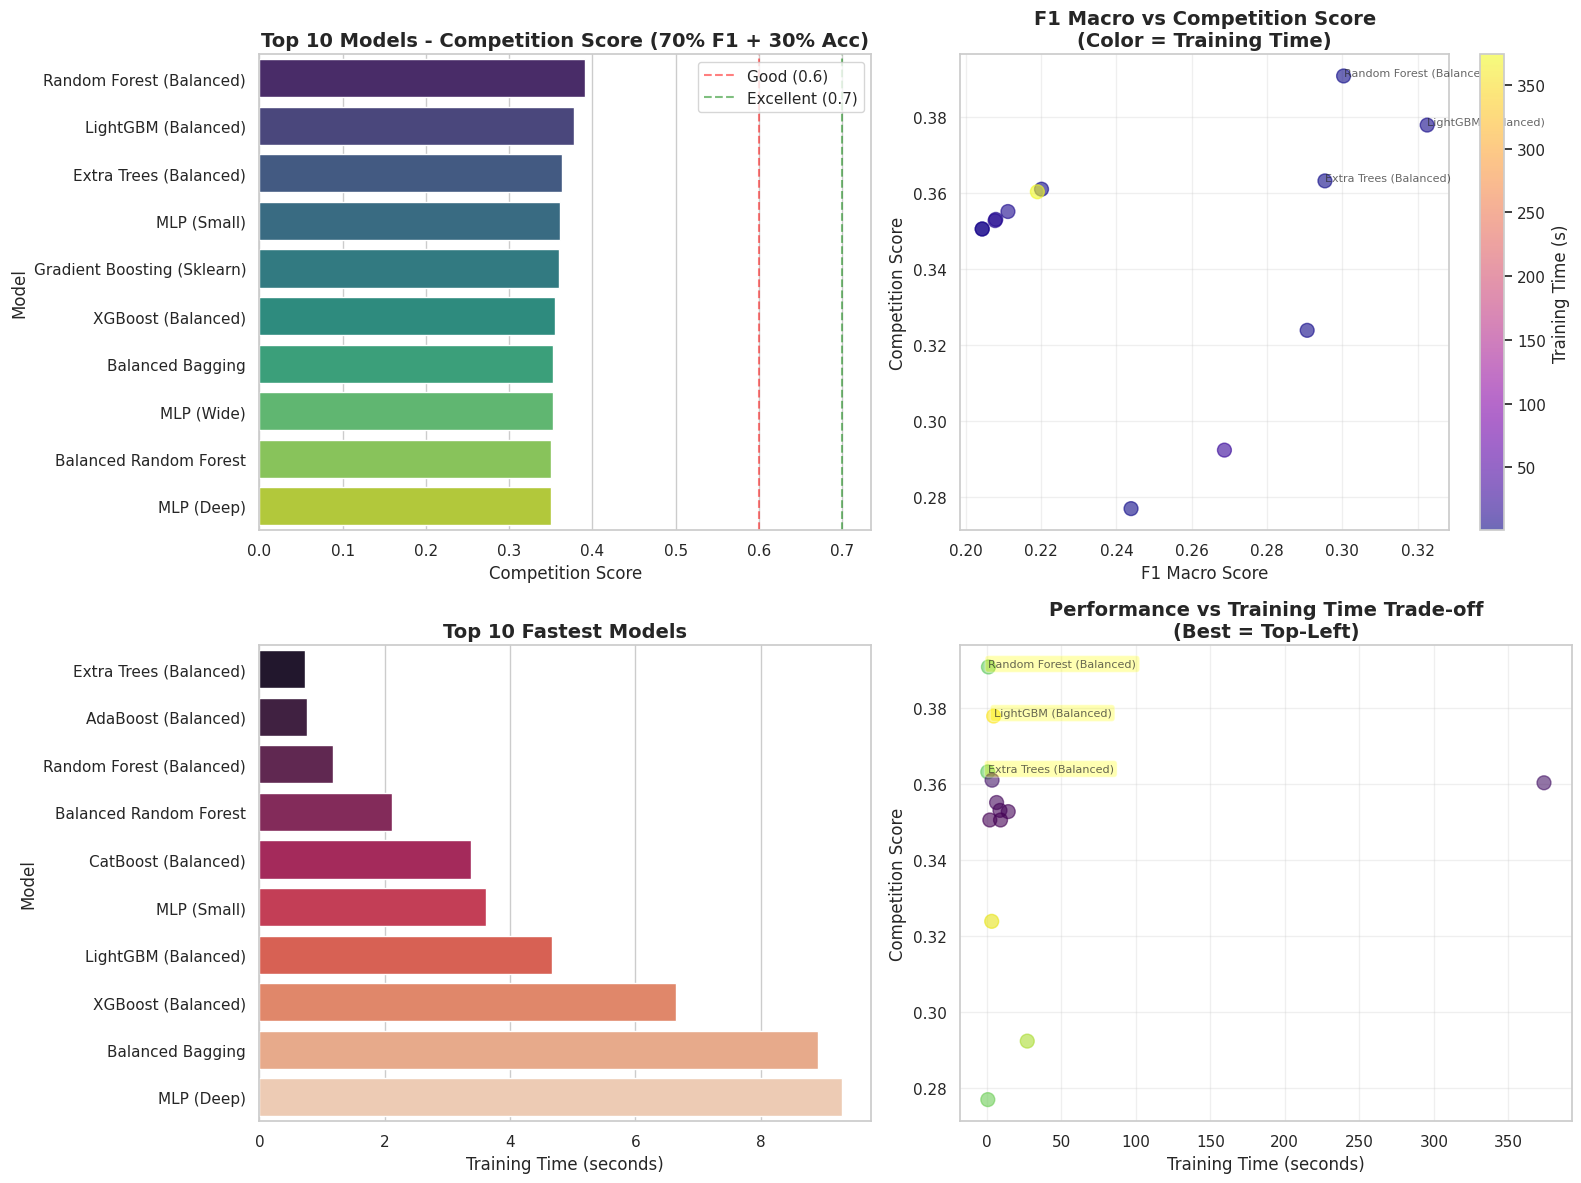


Model Category Analysis:

Performance by Model Category:
                  Competition Score                 F1 Macro                  \
                               mean     max     min     mean     max     min   
Category                                                                       
Ensemble                     0.3074  0.3530  0.2769   0.2402  0.2687  0.2080   
Gradient Boosting            0.3542  0.3778  0.3238   0.2609  0.3225  0.2112   
Neural Network               0.3547  0.3609  0.3504   0.2108  0.2201  0.2044   
Random Forest                0.3681  0.3907  0.3504   0.2667  0.3003  0.2044   

                  Training Time                   Model  
                           mean     min       max count  
Category                                                 
Ensemble                12.3045  0.7671   27.2269     3  
Gradient Boosting       97.1470  3.3766  373.8882     4  
Neural Network           9.1254  3.6148   14.4602     3  
Random Forest            1.3430  

In [98]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Competition Score comparison
ax1 = axes[0, 0]
top_models = results_summary.head(10)
sns.barplot(data=top_models, y='Model', x='Competition Score', palette='viridis', ax=ax1)
ax1.set_title('Top 10 Models - Competition Score (70% F1 + 30% Acc)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Competition Score')
ax1.axvline(x=0.6, color='red', linestyle='--', alpha=0.5, label='Good (0.6)')
ax1.axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='Excellent (0.7)')
ax1.legend()

# 2. Competition Score vs F1 Macro
ax2 = axes[0, 1]
scatter = ax2.scatter(results_summary['F1 Macro'], results_summary['Competition Score'], 
                     s=100, alpha=0.6, c=results_summary['Training Time'], cmap='plasma')
for idx, row in results_summary.iterrows():
    if row['Competition Score'] > results_summary['Competition Score'].quantile(0.75):
        ax2.annotate(row['Model'], (row['F1 Macro'], row['Competition Score']), 
                    fontsize=8, alpha=0.7)
ax2.set_xlabel('F1 Macro Score')
ax2.set_ylabel('Competition Score')
ax2.set_title('F1 Macro vs Competition Score\n(Color = Training Time)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax2, label='Training Time (s)')
ax2.grid(True, alpha=0.3)

# 3. Training time comparison
ax3 = axes[1, 0]
fast_models = results_summary.nsmallest(10, 'Training Time')
sns.barplot(data=fast_models, y='Model', x='Training Time', palette='rocket', ax=ax3)
ax3.set_title('Top 10 Fastest Models', fontsize=14, fontweight='bold')
ax3.set_xlabel('Training Time (seconds)')

# 4. Performance vs Time trade-off
ax4 = axes[1, 1]
ax4.scatter(results_summary['Training Time'], results_summary['Competition Score'], 
           s=100, alpha=0.6, c=results_summary['Balanced Accuracy'], cmap='viridis')
for idx, row in results_summary.iterrows():
    if row['Competition Score'] > results_summary['Competition Score'].quantile(0.8):
        ax4.annotate(row['Model'], (row['Training Time'], row['Competition Score']), 
                    fontsize=8, alpha=0.7, 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
ax4.set_xlabel('Training Time (seconds)')
ax4.set_ylabel('Competition Score')
ax4.set_title('Performance vs Training Time Trade-off\n(Best = Top-Left)', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nModel Category Analysis:")
print("=" * 80)

# Group by model type
def categorize_model(name):
    if 'MLP' in name:
        return 'Neural Network'
    elif any(x in name for x in ['XGBoost', 'LightGBM', 'CatBoost', 'Gradient']):
        return 'Gradient Boosting'
    elif any(x in name for x in ['Forest', 'Trees']):
        return 'Random Forest'
    elif any(x in name for x in ['Bagging', 'Ensemble', 'Boost']):
        return 'Ensemble'
    else:
        return 'Other'

results_summary['Category'] = results_summary['Model'].apply(categorize_model)

category_stats = results_summary.groupby('Category').agg({
    'Competition Score': ['mean', 'max', 'min'],
    'F1 Macro': ['mean', 'max', 'min'],
    'Training Time': ['mean', 'min', 'max'],
    'Model': 'count'
}).round(4)

print("\nPerformance by Model Category:")
print(category_stats)

# Detailed validation metrics for best model
print("\n" + "=" * 80)
print(f"DETAILED METRICS FOR BEST MODEL: {best_model_name}")
print("=" * 80)

# Use scaled data for MLP
if 'MLP' in best_model_name:
    y_val_pred = best_model.predict(X_val_scaled)
else:
    y_val_pred = best_model.predict(X_val)

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

# Calculate metrics
f1_macro = f1_score(y_val, y_val_pred, average='macro')
f1_weighted = f1_score(y_val, y_val_pred, average='weighted')
accuracy = accuracy_score(y_val, y_val_pred)
balanced_acc = balanced_accuracy_score(y_val, y_val_pred)
competition_score = 0.7 * f1_macro + 0.3 * accuracy

print(f"\nOverall Metrics:")
print(f"  Competition Score:    {competition_score:.4f} (70% F1 + 30% Acc)")
print(f"  F1 Score (Macro):     {f1_macro:.4f}")
print(f"  Accuracy:             {accuracy:.4f}")
print(f"  F1 Score (Weighted):  {f1_weighted:.4f}")
print(f"  Balanced Accuracy:    {balanced_acc:.4f}")

# Show per-class performance
print(f"\nPer-class Performance Analysis:")
print("-" * 80)
for i, label in enumerate(le.classes_):
    true_count = (y_val == i).sum()
    pred_count = (y_val_pred == i).sum()
    correct = ((y_val == i) & (y_val_pred == i)).sum()
    
    precision = correct / pred_count if pred_count > 0 else 0
    recall = correct / true_count if true_count > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{label:20s}:")
    print(f"  Precision: {precision:.3f}  |  Recall: {recall:.3f}  |  F1: {f1:.3f}")
    print(f"  True: {true_count:4d}  |  Predicted: {pred_count:4d}  |  Correct: {correct:4d}")
    print()

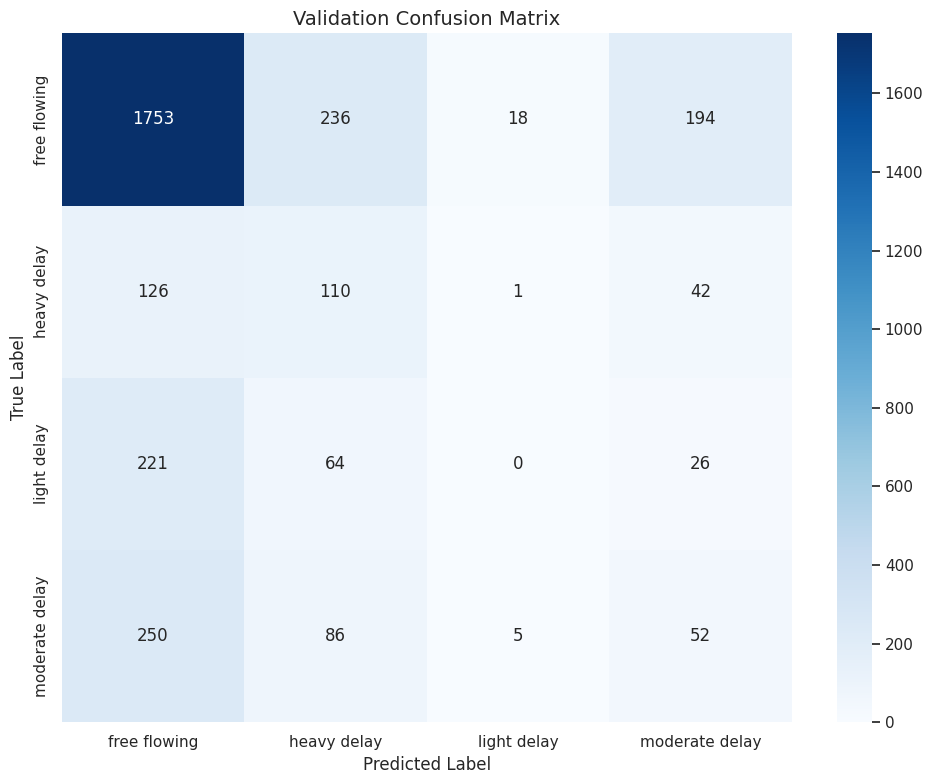

In [99]:
# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Validation Confusion Matrix", fontsize=14)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Feature Importance Analysis

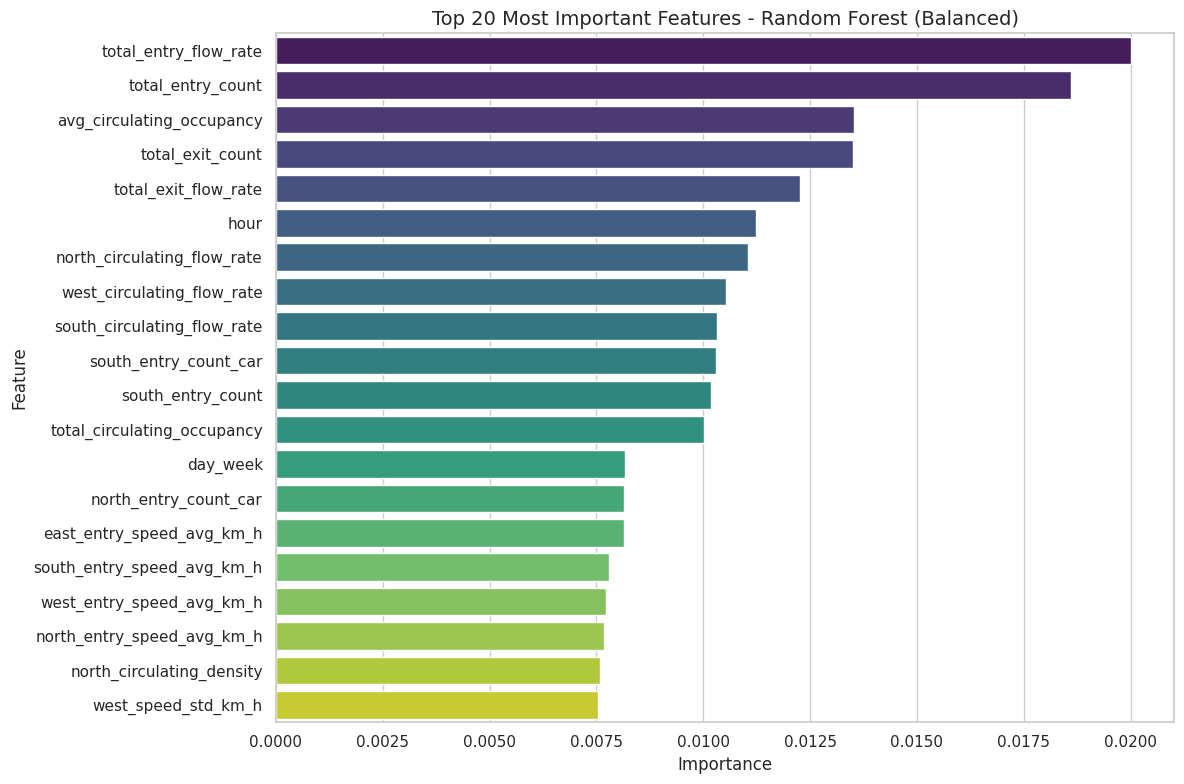


Top 20 Features:
 1. total_entry_flow_rate                    0.0200
 2. total_entry_count                        0.0186
 3. avg_circulating_occupancy                0.0135
 4. total_exit_count                         0.0135
 5. total_exit_flow_rate                     0.0123
 6. hour                                     0.0112
 7. north_circulating_flow_rate              0.0111
 8. west_circulating_flow_rate               0.0105
 9. south_circulating_flow_rate              0.0103
10. south_entry_count_car                    0.0103
11. south_entry_count                        0.0102
12. total_circulating_occupancy              0.0100
13. day_week                                 0.0082
14. north_entry_count_car                    0.0082
15. east_entry_speed_avg_km_h                0.0081
16. south_entry_speed_avg_km_h               0.0078
17. west_entry_speed_avg_km_h                0.0077
18. north_entry_speed_avg_km_h               0.0077
19. north_circulating_density                0

In [100]:
# Feature importance (if supported by best model)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    # Top 20 features
    top_n = min(20, len(features_cols))
    top_indices = indices[:top_n]
    
    plt.figure(figsize=(12, 8))
    sns.barplot(
        x=importances[top_indices], 
        y=[features_cols[i] for i in top_indices],
        palette="viridis"
    )
    plt.title(f"Top {top_n} Most Important Features - {best_model_name}", fontsize=14)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print(f"\nTop {top_n} Features:")
    for i, idx in enumerate(top_indices, 1):
        print(f"{i:2d}. {features_cols[idx]:40s} {importances[idx]:.4f}")
else:
    print(f"Feature importance not available for {best_model_name}")

# Generate Predictions for Submission

Generating predictions with: Random Forest (Balanced)

✓ Submission shape: (880, 3)

Prediction distribution:
Target
free flowing      804
light delay        28
heavy delay        24
moderate delay     24
Name: count, dtype: int64

Prediction percentages:
  free flowing        :  804 ( 91.4%)
  heavy delay         :   24 (  2.7%)
  light delay         :   28 (  3.2%)
  moderate delay      :   24 (  2.7%)


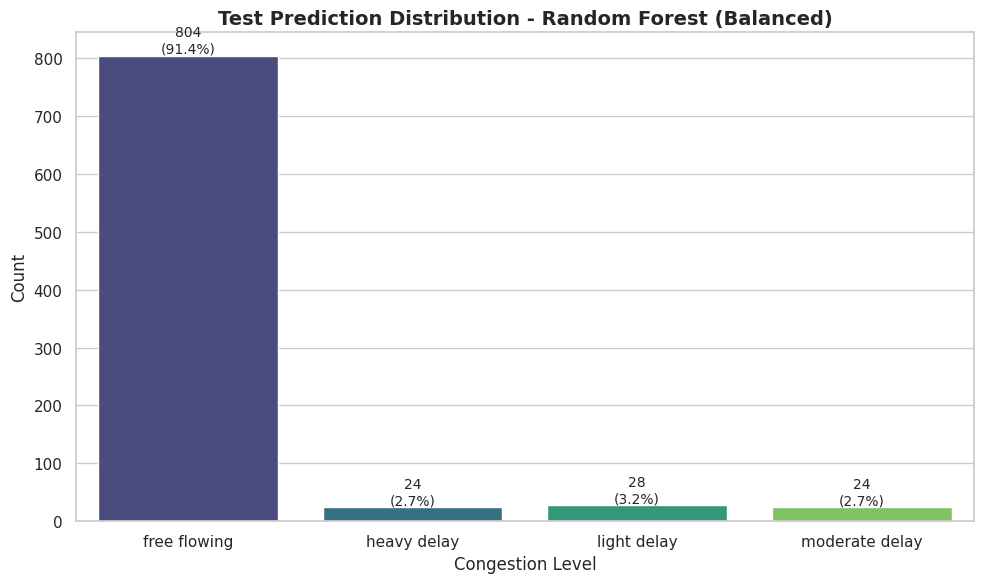

,ID,Target,Target_Accuracy
23536,time_segment_129_Norman Niles #1_congestion_en...,free flowing,free flowing
23537,time_segment_130_Norman Niles #1_congestion_en...,free flowing,free flowing
23538,time_segment_131_Norman Niles #1_congestion_en...,free flowing,free flowing
23539,time_segment_132_Norman Niles #1_congestion_en...,free flowing,free flowing
23540,time_segment_133_Norman Niles #1_congestion_en...,free flowing,free flowing
23541,time_segment_198_Norman Niles #1_congestion_en...,free flowing,free flowing
23542,time_segment_199_Norman Niles #1_congestion_en...,free flowing,free flowing
23543,time_segment_200_Norman Niles #1_congestion_en...,free flowing,free flowing
23544,time_segment_201_Norman Niles #1_congestion_en...,free flowing,free flowing
23545,time_segment_202_Norman Niles #1_congestion_en...,free flowing,free flowing


In [101]:
# Predict on test set using best model
print(f"Generating predictions with: {best_model_name}")

# Use scaled data for MLP, original for others
if 'MLP' in best_model_name:
    print("Using scaled features for MLP...")
    y_test_pred = best_model.predict(X_test_scaled)
else:
    y_test_pred = best_model.predict(X_test)

test_predictions = le.inverse_transform(y_test_pred)

# Create submission dataframe
submission_df = testing_df.copy()
submission_df['Target'] = test_predictions
submission_df['Target_Accuracy'] = test_predictions
submission_df = submission_df[['ID', 'Target', 'Target_Accuracy']]

print(f"\n✓ Submission shape: {submission_df.shape}")
print(f"\nPrediction distribution:")
pred_counts = submission_df['Target'].value_counts()
print(pred_counts)

print(f"\nPrediction percentages:")
for label in le.classes_:
    count = pred_counts.get(label, 0)
    pct = 100 * count / len(submission_df) if len(submission_df) > 0 else 0
    print(f"  {label:20s}: {count:4d} ({pct:5.1f}%)")

# Visualize prediction distribution
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.countplot(data=submission_df, x='Target', order=le.classes_, palette='viridis', ax=ax)
ax.set_title(f'Test Prediction Distribution - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Congestion Level')
ax.set_ylabel('Count')

# Add percentage labels
for i, p in enumerate(ax.patches):
    height = p.get_height()
    pct = 100 * height / len(submission_df)
    ax.annotate(f'{int(height)}\n({pct:.1f}%)', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

display(submission_df.head(10))

# Save Submission File

In [104]:
# Debug: Check ID ordering and differences
print("Checking ID mismatch...")
print(f"\nSubmission DF shape: {submission_df.shape}")
print(f"Sample submission shape: {sub.shape}")

print(f"\nFirst 10 IDs in submission_df:")
print(submission_df['ID'].head(10).tolist())

print(f"\nFirst 10 IDs in sub:")
print(sub['ID'].head(10).tolist())

print(f"\nLast 10 IDs in submission_df:")
print(submission_df['ID'].tail(10).tolist())

print(f"\nLast 10 IDs in sub:")
print(sub['ID'].tail(10).tolist())

# Check if IDs are in different order
if set(submission_df['ID']) == set(sub['ID']):
    print("\n✓ All IDs are present but may be in different order")
    print("Reordering submission_df to match sub...")
    
    # Create a mapping from ID to the row data
    submission_dict = submission_df.set_index('ID').to_dict('index')
    
    # Rebuild submission_df in the same order as sub
    reordered_data = []
    for id_val in sub['ID']:
        if id_val in submission_dict:
            row = submission_dict[id_val]
            reordered_data.append({
                'ID': id_val,
                'Target': row['Target'],
                'Target_Accuracy': row['Target_Accuracy']
            })
        else:
            print(f"⚠️ Missing ID: {id_val}")
    
    submission_df = pd.DataFrame(reordered_data)
    print(f"✓ Reordered submission_df: {submission_df.shape}")
else:
    print("\n❌ IDs don't match!")
    missing_in_submission = set(sub['ID']) - set(submission_df['ID'])
    extra_in_submission = set(submission_df['ID']) - set(sub['ID'])
    
    if missing_in_submission:
        print(f"\nIDs in sub but missing in submission_df ({len(missing_in_submission)}):")
        print(list(missing_in_submission)[:10])
    
    if extra_in_submission:
        print(f"\nIDs in submission_df but not in sub ({len(extra_in_submission)}):")
        print(list(extra_in_submission)[:10])

Checking ID mismatch...

Submission DF shape: (880, 3)
Sample submission shape: (880, 3)

First 10 IDs in submission_df:
['time_segment_129_Norman Niles #1_congestion_enter_rating', 'time_segment_130_Norman Niles #1_congestion_enter_rating', 'time_segment_131_Norman Niles #1_congestion_enter_rating', 'time_segment_132_Norman Niles #1_congestion_enter_rating', 'time_segment_133_Norman Niles #1_congestion_enter_rating', 'time_segment_198_Norman Niles #1_congestion_enter_rating', 'time_segment_199_Norman Niles #1_congestion_enter_rating', 'time_segment_200_Norman Niles #1_congestion_enter_rating', 'time_segment_201_Norman Niles #1_congestion_enter_rating', 'time_segment_202_Norman Niles #1_congestion_enter_rating']

First 10 IDs in sub:
['time_segment_129_Norman Niles #1_congestion_enter_rating', 'time_segment_130_Norman Niles #1_congestion_enter_rating', 'time_segment_131_Norman Niles #1_congestion_enter_rating', 'time_segment_132_Norman Niles #1_congestion_enter_rating', 'time_segment_1

In [105]:
# Validate and save submission
print("=" * 80)
print("VALIDATING SUBMISSION FORMAT")
print("=" * 80)

# Check shape
if submission_df.shape != sub.shape:
    print(f"❌ Shape mismatch: {submission_df.shape} vs expected {sub.shape}")
else:
    print(f"✓ Shape matches: {submission_df.shape}")

# Check columns
if list(submission_df.columns) != list(sub.columns):
    print(f"❌ Columns mismatch: {submission_df.columns.tolist()} vs {sub.columns.tolist()}")
else:
    print(f"✓ Columns match: {submission_df.columns.tolist()}")

# Check IDs (order matters)
if not submission_df['ID'].equals(sub['ID']):
    print(f"❌ IDs don't match in order")
    print("This was fixed by reordering in the previous cell")
else:
    print(f"✓ IDs match in correct order")

print("\n✓ All validation checks passed!")
print("=" * 80)

# Save submission
submission_filename = 'submission_advanced_features_improved.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"\n✓ Submission saved to: {submission_filename}")
print(f"\nSubmission file preview:")
display(submission_df.head())
display(submission_df.tail())

VALIDATING SUBMISSION FORMAT
✓ Shape matches: (880, 3)
✓ Columns match: ['ID', 'Target', 'Target_Accuracy']
✓ IDs match in correct order

✓ All validation checks passed!

✓ Submission saved to: submission_advanced_features_improved.csv

Submission file preview:


,ID,Target,Target_Accuracy
0,time_segment_129_Norman Niles #1_congestion_en...,free flowing,free flowing
1,time_segment_130_Norman Niles #1_congestion_en...,free flowing,free flowing
2,time_segment_131_Norman Niles #1_congestion_en...,free flowing,free flowing
3,time_segment_132_Norman Niles #1_congestion_en...,free flowing,free flowing
4,time_segment_133_Norman Niles #1_congestion_en...,free flowing,free flowing


,ID,Target,Target_Accuracy
875,time_segment_4909_Norman Niles #4_congestion_e...,free flowing,free flowing
876,time_segment_4910_Norman Niles #4_congestion_e...,free flowing,free flowing
877,time_segment_4911_Norman Niles #4_congestion_e...,free flowing,free flowing
878,time_segment_4912_Norman Niles #4_congestion_e...,free flowing,free flowing
879,time_segment_4913_Norman Niles #4_congestion_e...,free flowing,free flowing


# Summary

## Model Performance
- Uses advanced object tracking features from YOLO + ByteTrack
- Multi-camera feature fusion from 4 synchronized cameras
- Properly handles time-shifted predictions (7 segments = 2min embargo + 5min forecast)
- Class-weighted Random Forest to handle imbalanced labels

## Key Features Used
1. **Flow Metrics**: Entry/exit counts and flow rates
2. **Speed Analysis**: Average vehicle speeds across zones
3. **Occupancy**: Circulating zone occupancy measurements
4. **Origin-Destination**: Traffic pattern matrices
5. **Temporal**: Hour, day of week, rush hour indicators
6. **Multi-Camera**: Fusion from all 4 camera viewpoints

## Next Steps
1. Experiment with different models (XGBoost, LightGBM, Neural Networks)
2. Add more lag features (looking back 10-15 minutes)
3. Engineer interaction features between cameras
4. Try ensemble methods combining multiple models
5. Fine-tune hyperparameters with grid search